# Task 2: Multi-Grain Data, Abstraction, and Semantic Layering


## 1. Schema Inspection and Multi-Modal Domain Spectrum



In [ ]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6

os.makedirs('output_figures', exist_ok=True)
df_raw = pd.read_csv('steam-games.csv')
schema_audit = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Non-Null Count': df_raw.notnull().sum(),
    'Null Count': df_raw.isnull().sum(),
    'Null Rate (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})

print(f"Dataset Dimension: {df_raw.shape[0]:,} records x {df_raw.shape[1]} attributes | Unique app_id count: {df_raw['app_id'].nunique():,}")
print("\n--- SCHEMA AUDIT & DATA TYPE CLASSIFICATION ---")
print(schema_audit.head(12).to_string())


Dataset Dimension: 42,497 records x 24 attributes | Unique app_id count: 42,497

--- SCHEMA AUDIT & DATA TYPE CLASSIFICATION ---
                    Data Type  Non-Null Count  Null Count  Null Rate (%)
app_id                  int64           42497           0           0.00
title                     str           42497           0           0.00
release_date              str           42440          57           0.13
genres                    str           42410          87           0.20
categories                str           42452          45           0.11
developer                 str           42307         190           0.45
publisher                 str           42286         211           0.50
original_price            str            4859       37638          88.57
discount_percentage       str            4859       37638          88.57
discounted_price          str           42257         240           0.56
dlc_available           int64           42497           0           

## 2. Definition of the Atomic Entity Grain



In [11]:
sample_fact = df_raw.loc[df_raw['app_id'] == 730].iloc[0]

print("--- ATOMIC FACT INSTANTIATION (app_id: 730) ---")
print(f"• Title (Structured)        : {sample_fact['title']}")
print(f"• Price & Review Count      : Price={sample_fact['discounted_price']}, Overall %={sample_fact['overall_review_%']}, Reviews={sample_fact['overall_review_count']:,}")
print(f"• Genre Tags (Semi-Struct.) : {sample_fact['genres']}")
print(f"• Description (Unstructured): {sample_fact['about_description'][:100]}...")


--- ATOMIC FACT INSTANTIATION (app_id: 730) ---
• Title (Structured)        : Counter-Strike 2
• Price & Review Count      : Price=Free, Overall %=87.0, Reviews=8,062,218.0
• Genre Tags (Semi-Struct.) : Action, Free to Play
• Description (Unstructured): For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by mill...


## 3. Additive Fact Derivations & Base Semantic Layer Measures

In [12]:
def parse_price(val):
    if pd.isna(val): return np.nan
    val_str = str(val).strip().lower()
    if 'free' in val_str: return 0.0
    cleaned = re.sub(r'[^\d.]', '', val_str)
    try:
        p = float(cleaned)
        return round(p / 83.0, 2) if p > 100 else p
    except: return np.nan

df = df_raw.copy()
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df['price_usd'] = df['discounted_price'].apply(parse_price).fillna(df['original_price'].apply(parse_price))

df_clean = df.dropna(subset=['overall_review_%', 'overall_review_count']).copy()
df_clean = df_clean[df_clean['overall_review_count'] >= 10].copy()

df_clean['review_volume'] = df_clean['overall_review_count'].astype(int)
df_clean['satisfaction'] = df_clean['overall_review_%'].astype(float)
df_clean['positive_reviews'] = np.round(df_clean['review_volume'] * (df_clean['satisfaction'] / 100.0)).astype(int)
df_clean['negative_reviews'] = df_clean['review_volume'] - df_clean['positive_reviews']

df_clean['price_band'] = pd.cut(
    df_clean['price_usd'],
    bins=[-np.inf, 0, 9.99, 29.99, np.inf],
    labels=['Free ($0)', 'Budget (<$10)', 'Standard ($10-$30)', 'Premium (>$30)']
)

target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Casual', 'Indie']
def get_primary_genre(genre_str):
    if pd.isna(genre_str): return 'Other'
    genres = [g.strip() for g in str(genre_str).split(',')]
    for g in target_genres:
        if g in genres: return g
    return genres[0] if genres else 'Other'

df_clean['primary_genre'] = df_clean['genres'].apply(get_primary_genre)

df_core = df_clean[
    (df_clean['release_year'] >= 2014) & 
    (df_clean['release_year'] <= 2023) & 
    (df_clean['primary_genre'].isin(target_genres))
].copy()

print(f"Base Semantic Fact Table: N = {len(df_core):,} titles across {len(target_genres)} canonical genres (2014-2023).")


Base Semantic Fact Table: N = 35,540 titles across 7 canonical genres (2014-2023).


## 4. Dimensional OLAP Aggregations (Layer 2)


In [13]:
year_genre_agg = df_core.groupby(['release_year', 'primary_genre']).agg(
    title_count=('app_id', 'count'),
    total_reviews=('review_volume', 'sum'),
    median_satisfaction=('satisfaction', 'median'),
    weighted_satisfaction=('positive_reviews', lambda x: (x.sum() / df_core.loc[x.index, 'review_volume'].sum()) * 100.0),
    median_price=('price_usd', 'median')
).reset_index()

price_genre_agg = df_core.groupby(['price_band', 'primary_genre'], observed=True).agg(
    title_count=('app_id', 'count'),
    total_reviews=('review_volume', 'sum'),
    median_satisfaction=('satisfaction', 'median'),
    median_price=('price_usd', 'median')
).reset_index()

print("--- MID-LEVEL OLAP AGGREGATE: YEAR x GENRE (SAMPLE) ---")
print(year_genre_agg.head(6).to_string(index=False))


--- MID-LEVEL OLAP AGGREGATE: YEAR x GENRE (SAMPLE) ---
 release_year primary_genre  title_count  total_reviews  median_satisfaction  weighted_satisfaction  median_price
       2014.0        Action          561        2329307                 76.0              86.432660          4.20
       2014.0     Adventure          315         312442                 78.0              87.268997          4.16
       2014.0        Casual           60          20243                 76.0              84.883663          2.76
       2014.0         Indie           28          10914                 75.5              73.071285          4.20
       2014.0           RPG          100         249257                 76.0              82.986636          4.45
       2014.0    Simulation           73         256367                 64.0              89.366806          5.53


## 5. Strategic Executive KPIs (Layer 3) 


In [14]:
total_titles = len(df_core)
total_reviews = df_core['review_volume'].sum()
global_weighted_sat = (df_core['positive_reviews'].sum() / total_reviews) * 100.0
global_unweighted_sat = df_core['satisfaction'].mean()

titles_2014 = len(df_core[df_core['release_year'] == 2014])
titles_2023 = len(df_core[df_core['release_year'] == 2023])
cagr_titles = ((titles_2023 / titles_2014) ** (1 / 9) - 1) * 100.0

genre_summary = df_core.groupby('primary_genre').agg(
    titles=('app_id', 'count'),
    reviews=('review_volume', 'sum'),
    weighted_sat=('positive_reviews', lambda x: (x.sum() / df_core.loc[x.index, 'review_volume'].sum()) * 100.0)
)

print("========================================================================")
print("             STRATEGIC EXECUTIVE KPI SCORECARD (LAYER 3)                ")
print("========================================================================")
print(f"Catalog Total Titles (2014–2023)      : {total_titles:,}")
print(f"Market Review Volume                  : {total_reviews:,}")
print(f"Annual Catalog Growth (10-Yr CAGR)    : {cagr_titles:.2f}% per annum")
print(f"Platform Weighted Satisfaction (True) : {global_weighted_sat:.2f}%")
print(f"Platform Unweighted Mean Satisfaction : {global_unweighted_sat:.2f}% (Distortion Delta: -{global_weighted_sat - global_unweighted_sat:.2f}%)")
print(f"Market Median Price Point             : ${df_core['price_usd'].median():.2f} USD")
print("========================================================================")


             STRATEGIC EXECUTIVE KPI SCORECARD (LAYER 3)                
Catalog Total Titles (2014–2023)      : 35,540
Market Review Volume                  : 70,983,865
Annual Catalog Growth (10-Yr CAGR)    : 16.84% per annum
Platform Weighted Satisfaction (True) : 84.73%
Platform Unweighted Mean Satisfaction : 76.76% (Distortion Delta: -7.98%)
Market Median Price Point             : $4.20 USD


## 6. Empirical and Mathematical Proofs of Grain Misalignment

In [15]:
# 1. Proof 1: The Averaging Fallacy
trap1 = df_core.groupby('primary_genre').agg(
    titles=('app_id', 'count'),
    total_reviews=('review_volume', 'sum'),
    unweighted_mean=('satisfaction', 'mean'),
    weighted_mean=('positive_reviews', lambda x: (x.sum() / df_core.loc[x.index, 'review_volume'].sum()) * 100.0)
).reset_index()
trap1['distortion_delta_%'] = (trap1['weighted_mean'] - trap1['unweighted_mean']).round(2)
trap1['unweighted_mean'] = trap1['unweighted_mean'].round(2)
trap1['weighted_mean'] = trap1['weighted_mean'].round(2)

print("--- PROOF 1: THE AVERAGING FALLACY (UNWEIGHTED VS WEIGHTED) ---")
print(trap1.to_string(index=False))

# 2. Proof 2: Cartesian Tag Explosion
df_exploded = df_core.assign(genre_list=df_core['genres'].str.split(',')).explode('genre_list')
df_exploded['genre_clean'] = df_exploded['genre_list'].str.strip()
exploded_target = df_exploded[df_exploded['genre_clean'].isin(target_genres)]

trap2 = pd.DataFrame({
    'Unique_Primary_Count': df_core['primary_genre'].value_counts(),
    'Exploded_Tag_Count': exploded_target['genre_clean'].value_counts()
}).dropna()
trap2['Inflation_Factor'] = (trap2['Exploded_Tag_Count'] / trap2['Unique_Primary_Count']).round(2)

print("\n--- PROOF 2: CARTESIAN INFLATION IN MULTI-GENRE ARRAYS ---")
print(trap2.to_string())
print(f"Overall Market Cardinality Inflation: {len(df_core):,} unique titles -> {len(exploded_target):,} exploded rows ({len(exploded_target)/len(df_core):.2f}x)")

# 3. Proof 3: Temporal Aggregation vs. Interquartile Dispersion
trap3 = df_core.groupby('release_year')['satisfaction'].agg(
    median_sat='median',
    mean_sat='mean',
    iqr=lambda x: np.percentile(x, 75) - np.percentile(x, 25),
    min_sat='min',
    max_sat='max'
).round(2).reset_index()

print("\n--- PROOF 3: TEMPORAL CENTRAL TENDENCY VS TRUE DISPERSION ---")
print(trap3.head(6).to_string(index=False))

# 4. Proof 4: Small-Sample Bias
low_n_leaders = df_core[df_core['satisfaction'] == 100.0].sort_values('review_volume', ascending=True).head(5)
blockbusters = df_core.sort_values('review_volume', ascending=False).head(5)

print("\n--- PROOF 4: LOW-VOLUME STOCHASTIC OUTLIERS (N = 10) ---")
print(low_n_leaders[['title', 'primary_genre', 'review_volume', 'satisfaction']].to_string(index=False))
print("\n--- PROOF 4: HIGH-VOLUME PLATFORM ANCHORS (N > 500,000) ---")
print(blockbusters[['title', 'primary_genre', 'review_volume', 'satisfaction']].to_string(index=False))


--- PROOF 1: THE AVERAGING FALLACY (UNWEIGHTED VS WEIGHTED) ---
primary_genre  titles  total_reviews  unweighted_mean  weighted_mean  distortion_delta_%
       Action   15437       46031867            75.67          83.21                7.55
    Adventure    8191        8564700            78.59          87.97                9.38
       Casual    2847        1801059            81.01          90.47                9.46
        Indie    1153         648496            79.15          90.51               11.36
          RPG    1920        5186654            76.77          88.20               11.43
   Simulation    2406        3642495            73.81          85.02               11.22
     Strategy    3586        5108594            75.10          86.52               11.42

--- PROOF 2: CARTESIAN INFLATION IN MULTI-GENRE ARRAYS ---
            Unique_Primary_Count  Exploded_Tag_Count  Inflation_Factor
Action                     15437               15437              1.00
Adventure             

## 7. Supporting Multi-Grain Visual Analytics

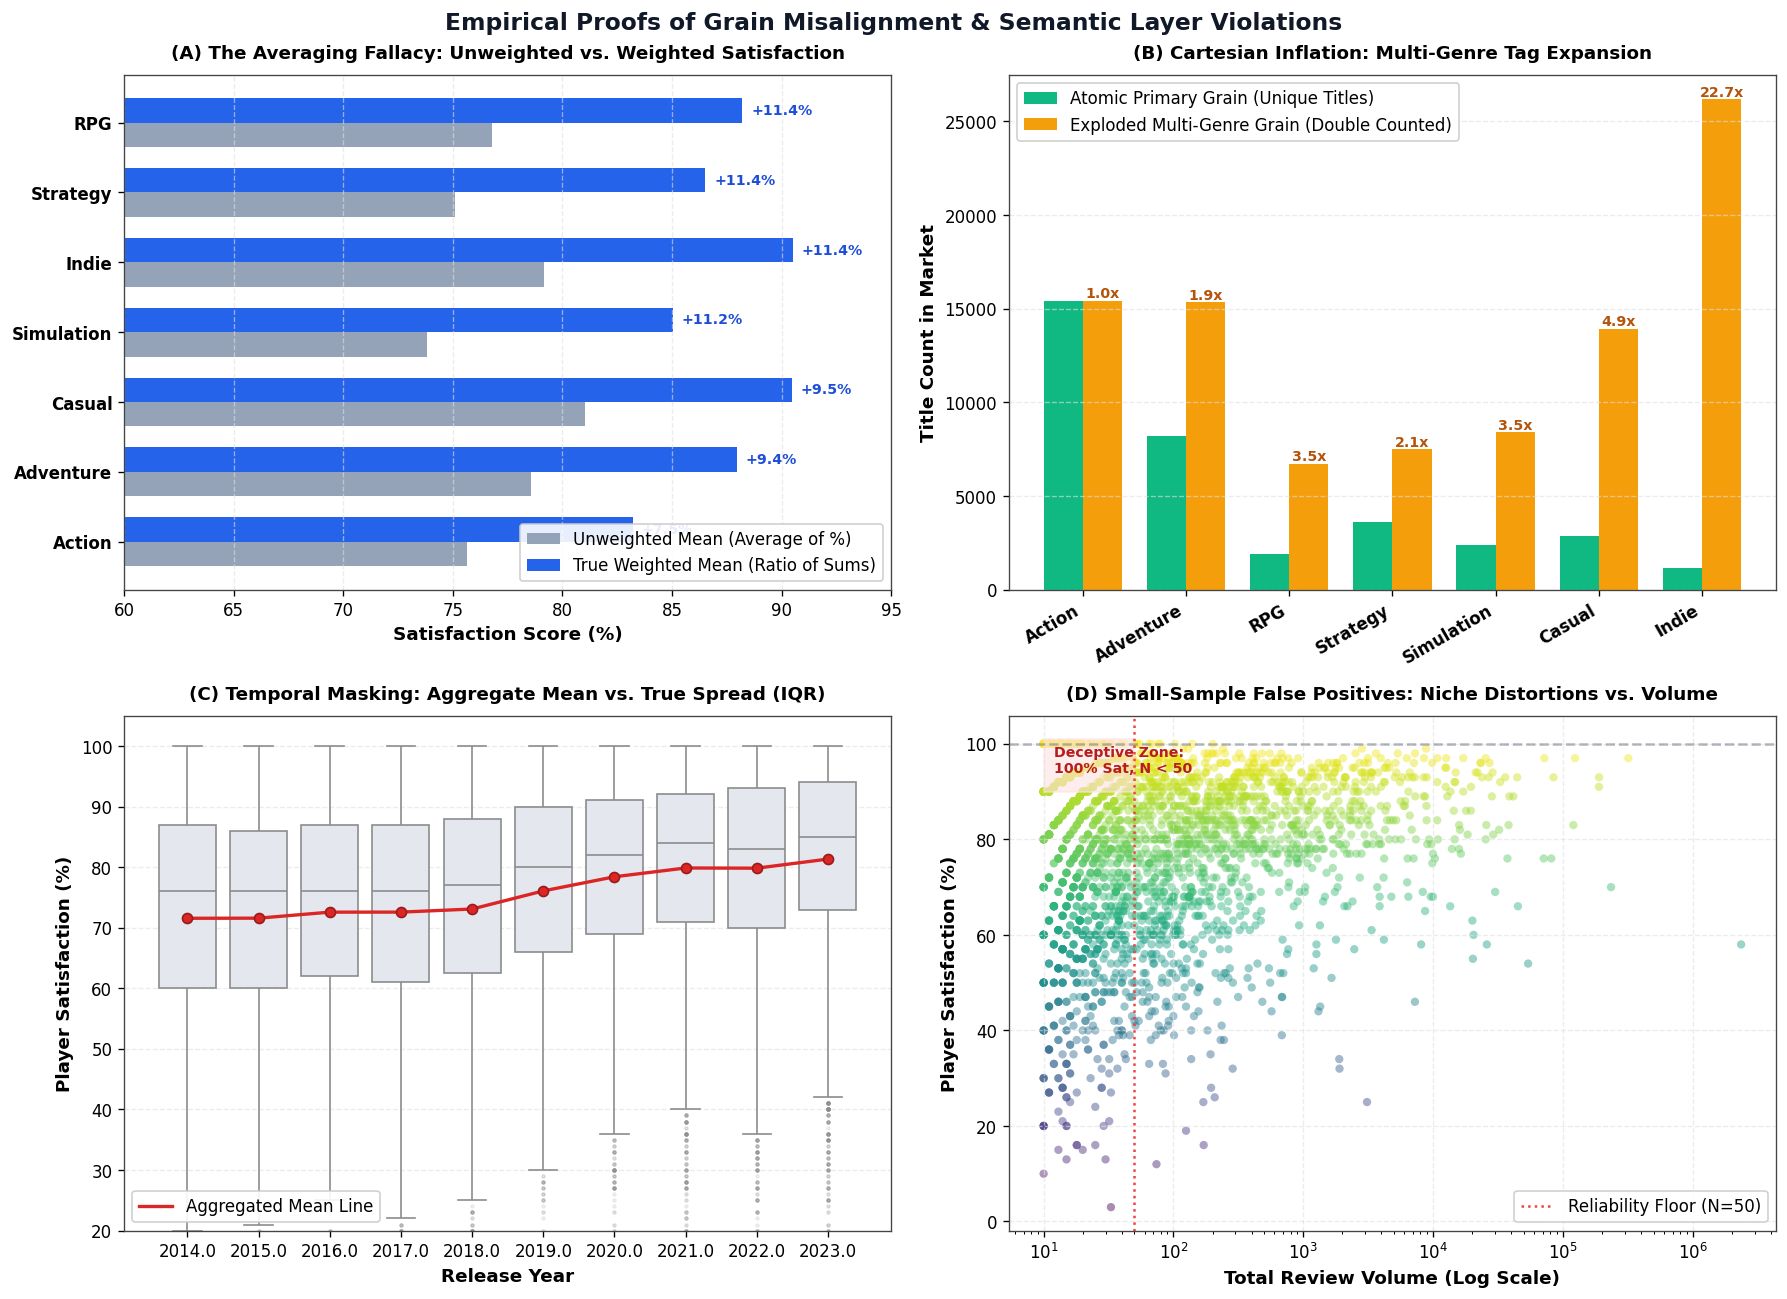

In [16]:

# Configure plot aesthetics
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#E0E0E0'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6
# Create 2x2 Figure Grid
fig, axes = plt.subplots(2, 2, figsize=(15, 11), dpi=120)
fig.suptitle(
    "Empirical Proofs of Grain Misalignment & Semantic Layer Violations",
    fontsize=14,
    fontweight='bold',
    y=0.98,
    color='#111827'
)
# -------------------------------------------------------------------------
# PANEL A: The Averaging Fallacy (Unweighted Mean vs. Volume-Weighted Mean)
# -------------------------------------------------------------------------
ax_a = axes[0, 0]
# Calculate metrics if not already defined
genre_metrics = []
for genre in target_genres:
    sub = df_core[df_core['primary_genre'] == genre]
    unweighted = sub['satisfaction'].mean()
    weighted = (sub['positive_reviews'].sum() / sub['review_volume'].sum()) * 100.0
    genre_metrics.append({
        'primary_genre': genre,
        'unweighted': unweighted,
        'weighted': weighted,
        'delta': weighted - unweighted
    })
df_gm = pd.DataFrame(genre_metrics).sort_values('delta')
y_pos = np.arange(len(df_gm))
bar_width = 0.35
ax_a.barh(y_pos - bar_width/2, df_gm['unweighted'], bar_width, label='Unweighted Mean (Average of %)', color='#94A3B8')
ax_a.barh(y_pos + bar_width/2, df_gm['weighted'], bar_width, label='True Weighted Mean (Ratio of Sums)', color='#2563EB')
ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(df_gm['primary_genre'], fontweight='semibold')
ax_a.set_xlim(60, 95)
ax_a.set_xlabel("Satisfaction Score (%)", fontweight='semibold')
ax_a.set_title("(A) The Averaging Fallacy: Unweighted vs. Weighted Satisfaction", fontsize=11, fontweight='bold', pad=10)
ax_a.grid(True, axis='x', linestyle='--', alpha=0.6)
ax_a.legend(loc='lower right', framealpha=0.9)
for i, delta in enumerate(df_gm['delta']):
    val = df_gm['weighted'].iloc[i]
    ax_a.text(val + 0.4, y_pos[i] + bar_width/2, f"+{delta:.1f}%", va='center', fontsize=8.5, fontweight='bold', color='#1D4ED8')
# -------------------------------------------------------------------------
# PANEL B: Cartesian Inflation (Multi-Genre Explosion)
# -------------------------------------------------------------------------
ax_b = axes[0, 1]
df_exp = df_core.assign(genre_list=df_core['genres'].str.split(',')).explode('genre_list')
df_exp['genre_clean'] = df_exp['genre_list'].str.strip()
exploded_counts = df_exp[df_exp['genre_clean'].isin(target_genres)]['genre_clean'].value_counts()
primary_counts = df_core['primary_genre'].value_counts()
genres_b = [g for g in target_genres if g in primary_counts.index]
x_b = np.arange(len(genres_b))
width_b = 0.38
p_vals = [primary_counts[g] for g in genres_b]
e_vals = [exploded_counts.get(g, 0) for g in genres_b]
ax_b.bar(x_b - width_b/2, p_vals, width_b, label='Atomic Primary Grain (Unique Titles)', color='#10B981')
ax_b.bar(x_b + width_b/2, e_vals, width_b, label='Exploded Multi-Genre Grain (Double Counted)', color='#F59E0B')
ax_b.set_xticks(x_b)
ax_b.set_xticklabels(genres_b, rotation=30, ha='right', fontweight='semibold')
ax_b.set_ylabel("Title Count in Market", fontweight='semibold')
ax_b.set_title("(B) Cartesian Inflation: Multi-Genre Tag Expansion", fontsize=11, fontweight='bold', pad=10)
ax_b.grid(True, axis='y', linestyle='--', alpha=0.6)
ax_b.legend(loc='upper left', framealpha=0.9)
for i in range(len(genres_b)):
    factor = e_vals[i] / p_vals[i] if p_vals[i] > 0 else 0
    ax_b.text(x_b[i] + width_b/2, e_vals[i] + 150, f"{factor:.1f}x", ha='center', fontsize=8.5, fontweight='bold', color='#B45309')
# -------------------------------------------------------------------------
# PANEL C: Temporal Masking (Distribution Spread vs. Aggregated Mean)
# -------------------------------------------------------------------------
ax_c = axes[1, 0]
sns.boxplot(
    x='release_year', y='satisfaction', data=df_core, ax=ax_c, color='#E2E8F0',
    showmeans=True, meanprops={"marker":"o", "markerfacecolor":"#DC2626", "markeredgecolor":"#991B1B", "markersize":6},
    flierprops={"marker":".", "alpha":0.2, "markersize":3}
)
annual_means = df_core.groupby('release_year')['satisfaction'].mean().values
ax_c.plot(np.arange(len(sorted(df_core['release_year'].unique()))), annual_means, color='#DC2626', linewidth=2, label='Aggregated Mean Line')
ax_c.set_title("(C) Temporal Masking: Aggregate Mean vs. True Spread (IQR)", fontsize=11, fontweight='bold', pad=10)
ax_c.set_xlabel("Release Year", fontweight='semibold')
ax_c.set_ylabel("Player Satisfaction (%)", fontweight='semibold')
ax_c.set_ylim(20, 105)
ax_c.grid(True, axis='y', linestyle='--', alpha=0.6)
ax_c.legend(loc='lower left', framealpha=0.9)
# -------------------------------------------------------------------------
# PANEL D: Small-Sample Distortion (Law of Small Numbers)
# -------------------------------------------------------------------------
ax_d = axes[1, 1]
sample_df = df_core.sample(n=min(2500, len(df_core)), random_state=42)
sc = ax_d.scatter(sample_df['review_volume'], sample_df['satisfaction'], 
                  c=sample_df['satisfaction'], cmap='viridis', alpha=0.45, s=25, edgecolors='none')
ax_d.set_xscale('log')
ax_d.set_title("(D) Small-Sample False Positives: Niche Distortions vs. Volume", fontsize=11, fontweight='bold', pad=10)
ax_d.set_xlabel("Total Review Volume (Log Scale)", fontweight='semibold')
ax_d.set_ylabel("Player Satisfaction (%)", fontweight='semibold')
ax_d.axvline(x=50, color='#EF4444', linestyle=':', linewidth=1.5, label='Reliability Floor (N=50)')
ax_d.axhline(y=100, color='#6B7280', linestyle='--', alpha=0.5)
# Deceptive zone highlighting
ax_d.fill_between([10, 50], [90, 90], [101, 101], color='#FEE2E2', alpha=0.6)
ax_d.text(12, 94, "Deceptive Zone:\n100% Sat, N < 50", fontsize=8.5, color='#B91C1C', fontweight='bold')
ax_d.grid(True, linestyle='--', alpha=0.6)
ax_d.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()
